In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import correlate, correlation_lags, find_peaks
import scipy.io.wavfile as wav
import IPython

## Άσκηση - Αφαίρεση Ηχούς

Ένα πολύ σημαντικό - και ακόμα ερευνητικά ενεργό - πρόβλημα στην Επεξεργασία Σήματος είναι η αφαίρεση της ηχούς - (echo cancellation) από μια ηχογράφηση. Σε αυτήν την άσκηση θα προσπαθήσουμε να αφαιρέσουμε ηχώ από ένα σήμα με τη βοήθεια της αυτοσυσχέτισης!!

(αʹ) Σας δίνονται δυο αρχεία της μορφής `echo-type_echo.wav`, στα οποία ξεκινά η ηχώ από ένα χρονικό σημείο. Σε καθένα από αυτά η ηχώ καθυστερεί όλο και περισσότερο, κάνοντας το αποτέλεσμα πολύ ενοχλητικό. Φορτώστε τα στην Python, δείτε τα, και ακούστε τα - διαδοχικά, εκτελώντας τις εντολές ανά ζεύγος - με τις εντολές:

In [2]:
fs, s1 = wav.read('./files/medium_echo.wav')
s1 = s1/max(abs(s1))  # Normalize audio in [-1, 1]
IPython.display.Audio(s1, rate=fs)  

In [3]:
fs, s2 = wav.read('./files/heavy_echo.wav')  
s2 = s2/max(abs(s2)) # Normalize audio in [-1, 1]
IPython.display.Audio(s2, rate=fs)  

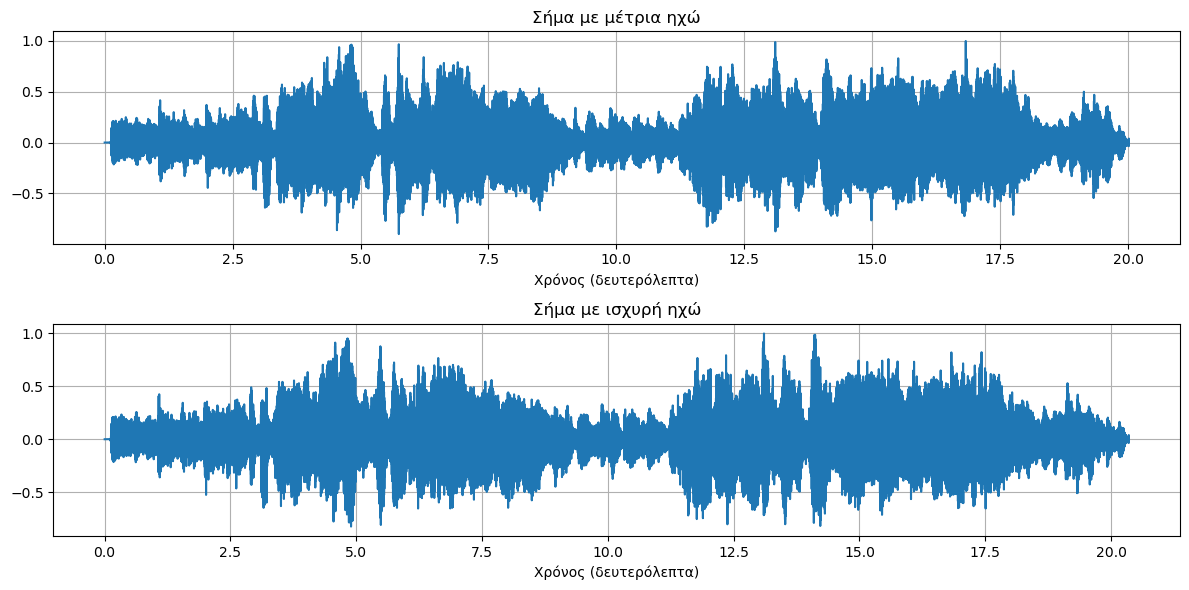

In [4]:
# Απεικόνιση των σημάτων
t1 = np.arange(0, len(s1)/fs, 1/fs)
t2 = np.arange(0, len(s2)/fs, 1/fs)

plt.figure(figsize=(12,6))

plt.subplot(2, 1, 1)
plt.plot(t1, s1)
plt.title("Σήμα με μέτρια ηχώ")
plt.xlabel('Χρόνος (δευτερόλεπτα)')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t2, s2)
plt.title("Σήμα με ισχυρή ηχώ")
plt.xlabel('Χρόνος (δευτερόλεπτα)')
plt.grid()

plt.tight_layout()
plt.show()
plt.close()

Στη συζήτηση που ακολουθεί ϑα αναφερόμαστε σε ένα αρχείο εξ΄ αυτών των δυο, για λόγους απλότητας. Εσείς πρέπει να επαναλάβετε τη διαδικασία που ϑα ακολουθήσουμε και για τα δυο αρχεία με ηχώ.

(βʹ) Η κρουστική απόκριση ενός συστήματος που προσθέτει ένα στιγμιότυπο ηχούς πλάτους $a$ με καθυστέρηση $t_d$ στην είσοδό του δίνεται ως:

$$h(t) = \delta(t) + a\delta(t − t_d)$$

του οποίου η απόκριση σε συχνότητα $H(f)$ είναι - όπως μπορείτε και εσείς να επιβεβαιώσετε:

$$H(f) = 1 + ae^{−j2\pi ft_d}$$

Αυτό το σύστημα έχει χρησιμοποιηθεί για να παραχθούν τα παραπάνω μουσικά κομμάτια, με δυο διαφορετικά ζεύγη τιμών για τα $(a, t_d)$ - που εσείς δε γνωρίζετε 😬.

Εσείς θέλετε ένα νέο σύστημα που να ακυρώνει το παραπάνω σύστημα, δηλ. ένα λεγόμενο αντίστροφο σύστημα $h^{\mathrm{inv}}(t)$, το οποίο αν το συνδέσουμε σε σειρά με το παραπάνω σύστημα $h(t)$ (ή αλλιώς, αν πάρουμε την έξοδο του $h(t)$ και την βάλουμε είσοδο στο $h^{\mathrm{inv}}(t)$, θα ακυρώνει την επίδραση του $h(t)$ σε μια οποιαδήποτε είσοδο $x(t)$. 

Αυτή η διαδικασία περιγράφεται με όρους συστημάτων ως εξής

$$y_{\mathrm{final}}(t) = x(t) * h(t) * h_{\mathrm{inv}}(t) = x(t)$$

Από αυτήν την σχέση εύκολα βλέπουμε ότι για να ισχύει, θα πρέπει

$$h(t)*h^{\mathrm{inv}}(t) = \delta(t)$$

Το αντίστροφο σύστημα μπορεί εύκολα να βρεθεί στο χώρο της συχνότητας. Έχουμε

$$h(t)*h^{\mathrm{inv}}(t) = \delta(t) \longleftrightarrow H(f)H^{\mathrm{inv}}(f) = 1$$

και άρα

$$H^{\mathrm{inv}}(f) = \frac{1}{H(f)} = \frac{1}{1+ae^{-j2\pi f t_d}}$$

Όμως, ξέρουμε ότι για ένα οποιοδήποτε σύστημα $H(f)$ ισχύει

$$H(f) = \frac{Y(f)}{X(f)}$$

και άρα

$$\frac{Y(f)}{X(f)} = \frac{1}{1+ae^{-j2\pi f t_d}} \iff Y(f) + aY(f)e^{-j2\pi f t_d} = X(f)$$

και εύκολα βρίσκουμε, με χρήση ιδιοτήτων μετασχηματισμού Fourier, ότι

$$y(t) + ay(t-t_d) = x(t)$$

Αυτό είναι λοιπόν το σύστημα που αν πάρει ως είσοδο $x(t)$ **ένα σήμα με ηχώ** που ξεκινά τη χρονική στιγμή $t_d$ και έχει πλάτος ηχούς $a$, θα αναλάβει να την ακυρώσει, και να μας επιστρέψει ως έξοδο $y(t)$, **ένα σήμα καθαρό από ηχώ**!

(γ') Όμως για να μπορέσουμε να το υλοποιήσουμε, χρειαζόμαστε να ξέρουμε πότε ξεκινά η ηχώ στο σήμα μας, δηλ. τη χρονική στιγμή $t_d$ - αν υποθέσουμε ότι το πλάτος $a$ της ηχούς μας είναι γνωστό (που στην πραγματικότητα δε θα είναι ποτέ γνωστό 😞). Παρατηρώντας το σήμα στο χρόνο, είναι αδύνατο να βρούμε πότε ξεκινά η ηχώ (δείτε τα σχήματα που τυπώσατε παραπάνω για να το επιβεβαιώσετε). 

Όμως, γνωρίζουμε από τη θεωρία ότι η **συνάρτηση αυτοσυσχέτισης** είναι μια συνάρτηση που συγκρίνει ένα σήμα με τον εαυτό του και μας βοηθά να βρούμε ομοιότητες. Επίσης, γνωρίζουμε ότι η αυτοσυσχέτιση λειτουργεί συγκρίνοντας μετατοπισμένες εκδόσεις ενός σήματος με τον εαυτό του, και παίρνει ως συνάρτηση μεγάλες τιμές όταν υπάρχουν μεγάλες ομοιότητες μεταξύ ενός σήματος και του μετατοπισμένου κατά $\tau$ εαυτού του.

Θα μπορούσε κανείς λοιπόν να σκεφτεί ότι η ηχώ, ως καθυστερημένο και μικρότερου πλάτους (ακριβές!) αντίγραφο του σήματος, σίγουρα θα έχει ομοιότητες με το τμήμα του σήματος που δεν έχει ηχώ (αυτό το μικρής διάρκειας κομμάτι στην αρχή της ηχογράφησης που ακούτε ότι είναι καθαρό - δηλ. δεν του έχει προστεθεί ηχώ γιατί ακόμα δεν έχει φτάσει στο μικρόφωνο). Οπότε αν εκτελέσουμε την πράξη της αυτοσυσχέτισης, σίγουρα θα βρούμε μια υψηλή τιμή της όταν το κομμάτι του σήματος πριν αρχίσει η ηχώ συμπέσει με το κομμάτι του σήματος που αρχίζει η ηχώ. Πότε συμβαίνει αυτό όμως; Μα φυσικά, τη χρονική στιγμή (δηλ. σε μετατόπιση του ενός σήματος ως προς το άλλο) $\tau = t_d$!

(δʹ) Η συνάρτηση $\texttt{correlate}$ της $\texttt{SciPy}$ (ή της $\texttt{NumPy}$) μπορεί να υπολογίσει την αυτοσυσχέτιση δυο (διακριτού χρόνου) σημάτων, και επιστρέφει τις τιμές της αυτοσυσχέτισης για τις διάφορες μετατοπίσεις $\tau$. Εκτελέστε:

In [5]:
help(correlate)

Help on function correlate in module scipy.signal._signaltools:

correlate(in1, in2, mode='full', method='auto')
    Cross-correlate two N-dimensional arrays.
    
    Cross-correlate `in1` and `in2`, with the output size determined by the
    `mode` argument.
    
    Parameters
    ----------
    in1 : array_like
        First input.
    in2 : array_like
        Second input. Should have the same number of dimensions as `in1`.
    mode : str {'full', 'valid', 'same'}, optional
        A string indicating the size of the output:
    
        ``full``
           The output is the full discrete linear cross-correlation
           of the inputs. (Default)
        ``valid``
           The output consists only of those elements that do not
           rely on the zero-padding. In 'valid' mode, either `in1` or `in2`
           must be at least as large as the other in every dimension.
        ``same``
           The output is the same size as `in1`, centered
           with respect to the 'f

 για να δείτε το documentation, και χρησιμοποιήστε τη για να βρείτε το αποτέλεσμα της αυτοσυσχέτισης. Μια και οι ηχογραφήσεις που σας δίνονται είναι σήματα διακριτού χρόνου (όταν τα φορτώνετε στην Python), μπορείτε να τη χρησιμοποιήσετε κατευθείαν, χωρίς προσεγγίσεις συνεχούς χρόνου. Χρησιμοποιήστε τη σύνταξη της $\texttt{correlate}$ που επιστρέφει την αυτοσυσχέτιση, και σας δίνεται η χρήση της $\texttt{correlation\_lags}$ για να πάρετε τον άξονα του χρόνου (lags) της αυτοσυσχέτισης, δηλ. το γνωστό άξονα $\tau$.

In [6]:
# Autocorrelations:

ac1 = correlate(s1, s1, mode="full") 
ac2 = correlate(s2, s2, mode="full")

# Άξονες του χρόνου τ της αυτοσυσχέτισης καθενός σήματος
lags1 = correlation_lags(len(s1), len(s1), mode="full")
lags2 = correlation_lags(len(s2), len(s2), mode="full")

(εʹ) Παρακάτω σας δίνονται οι γραφικές παραστάσεις της αυτοσυσχέτισης για καθένα σήμα.

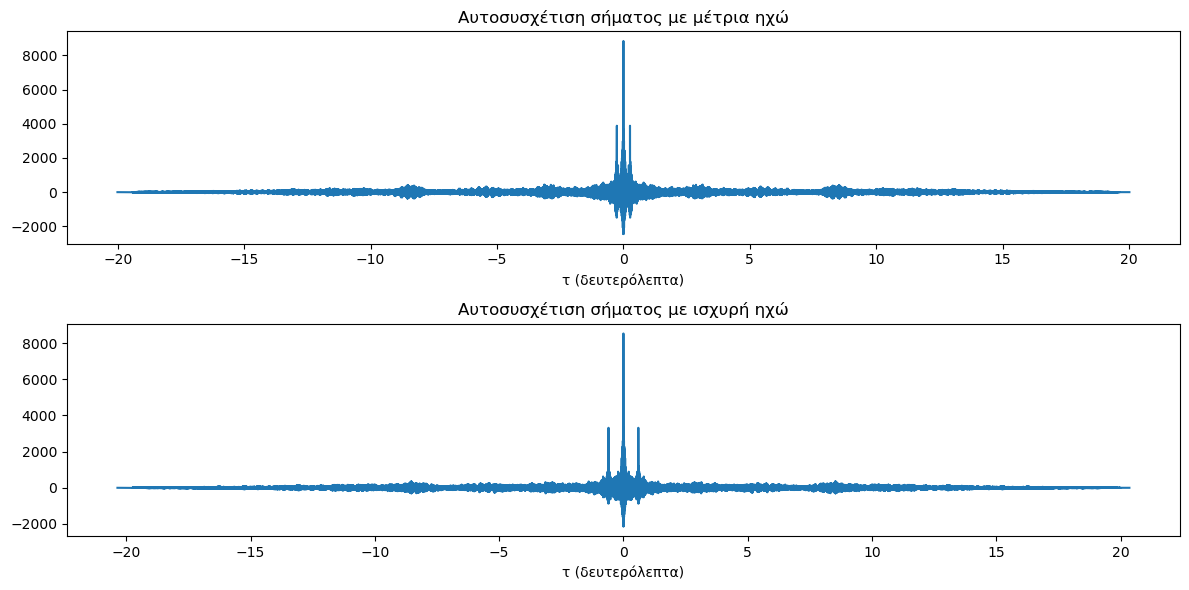

In [7]:
# Autocorrelation plots:

plt.figure(figsize=(12,6))

plt.subplot(2, 1, 1)
plt.plot(lags1/fs, ac1)
plt.title("Αυτοσυσχέτιση σήματος με μέτρια ηχώ")
plt.xlabel("τ (δευτερόλεπτα)")

plt.subplot(2, 1, 2)
plt.plot(lags2/fs, ac2)
plt.title("Αυτοσυσχέτιση σήματος με ισχυρή ηχώ")
plt.xlabel("τ (δευτερόλεπτα)")

plt.tight_layout()
plt.show()
plt.close()

στ) Βλέπετε παραπάνω σε κάθε σχήμα ότι η μέγιστη τιμή της αυτοσυσχέτισης βρίσκεται στο $\tau = 0$. Αναμενόμενο, μια και στη θεωρία έχουμε δείξει ότι για σήματα ενέργειας 

$$|\phi_x(\tau)| \leq \phi_x(0), \: \: \forall \tau$$

**ΟΜΩΣ** πρέπει να παρατηρείτε και δυο σχετικά ισχυρά πλάτη κοντά στο $\tau = 0$. Μπορούμε να αγνοήσουμε τον αρνητικό ημιάξονα βέβαια, καθώς περιέχει την ίδια πληροφορία με τον θετικό (λόγω αρτιότητας της αυτοσυσχέτισης). Η χρονική στιγμή $\tau$ που βρίσκονται αυτά τα ισχυρά πλάτη αποτελούν χρονική στιγμή μεγάλης ομοιότητας του σήματος με τον εαυτό του - σίγουρα είναι το χρονικό σημείο που η ηχώ ξεκινά!!!

Πώς μπορούμε να βρούμε τις χρονικές αυτές στιγμές? Μπορούμε να το κάνουμε from scratch αλλά ας μη σας ταλαιπωρήσουμε 😁. Η συνάρτηση $\texttt{find\_peaks}$ της βιβλιοθήκης $\texttt{scipy.signal}$ λαμβάνει ως όρισμα ένα python array και βρίσκει όλες τις *θέσεις* τοπικών μεγίστων του (ως δείκτες του array, δηλ. ακέραιους αριθμούς), ενώ μπορούμε να ζητήσουμε να επιστρέψει τις θέσεις των μεγίστων **που υπερβαίνουν ένα συγκεκριμένο πλάτος**!

Δείτε παρακάτω το documentation της.

In [8]:
help(find_peaks)

Help on function find_peaks in module scipy.signal._peak_finding:

find_peaks(x, height=None, threshold=None, distance=None, prominence=None, width=None, wlen=None, rel_height=0.5, plateau_size=None)
    Find peaks inside a signal based on peak properties.
    
    This function takes a 1-D array and finds all local maxima by
    simple comparison of neighboring values. Optionally, a subset of these
    peaks can be selected by specifying conditions for a peak's properties.
    
    Parameters
    ----------
    x : sequence
        A signal with peaks.
    height : number or ndarray or sequence, optional
        Required height of peaks. Either a number, ``None``, an array matching
        `x` or a 2-element sequence of the former. The first element is
        always interpreted as the  minimal and the second, if supplied, as the
        maximal required height.
    threshold : number or ndarray or sequence, optional
        Required threshold of peaks, the vertical distance to its ne

Παρατηρήστε τα γραφήματα των αυτοσυσχετίσεων παραπάνω και καλέστε την $\texttt{find\_peaks}$ με κατάλληλες παραμέτρους ώστε να σας επιστρέψουν *μεταξύ άλλων* τη θέση των τριών μεγίστων που φαίνονται "με το μάτι" στα παραπάνω γραφήματα.

Οι θέσεις τοπικών μεγίστων ως δείκτες του array ac1 που βρήκα είναι οι [316039 320199 324359].
Οι θέσεις τοπικών μεγίστων ως δείκτες του array ac2 που βρήκα είναι οι [316039 325457 325639 325821 335239].


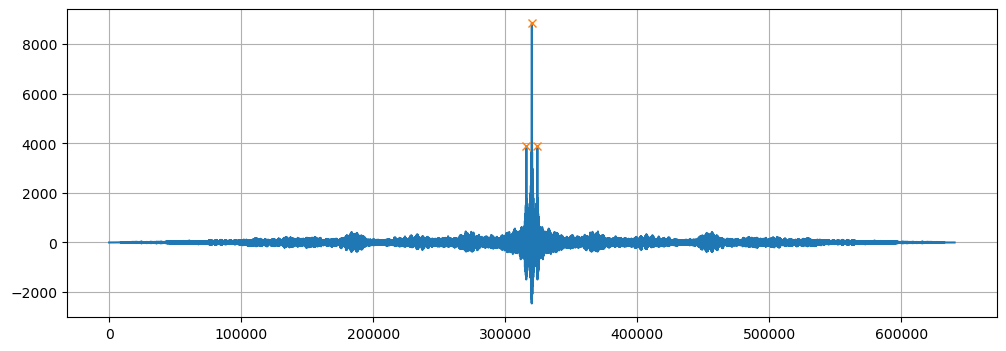

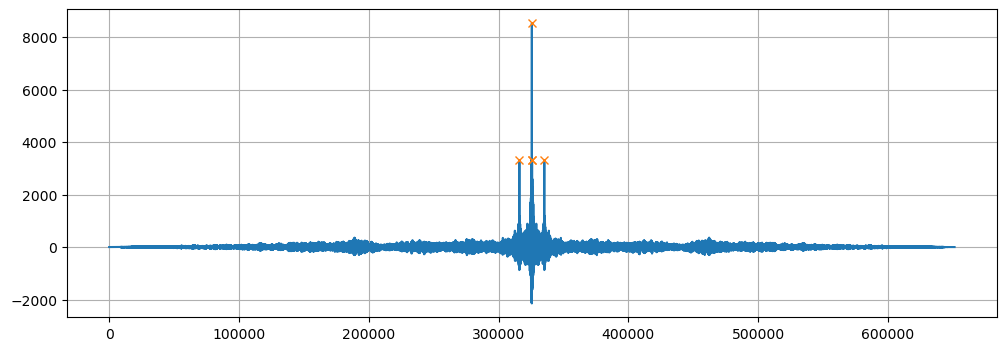

In [9]:
height1 = 3800 # Πειραματιστείτε με βάση τα σχήματα παραπάνω (θα χρειαστείτε τιμές > 3000)
height2 = 3300 # Πειραματιστείτε με βάση τα σχήματα παραπάνω (θα χρειαστείτε τιμές > 3000)

idx1, _ = find_peaks(ac1, height=height1)
idx2, _ = find_peaks(ac2, height=height2)

print(f"Οι θέσεις τοπικών μεγίστων ως δείκτες του array ac1 που βρήκα είναι οι {idx1}.")
print(f"Οι θέσεις τοπικών μεγίστων ως δείκτες του array ac2 που βρήκα είναι οι {idx2}.")

# Τα παρακάτω σχήματα θα σας δώσουν την αυτοσυσχέτιση κάθε σήματος και πάνω της σημειωμένα τα τοπικά μέγιστα που βρήκε η συνάρτηση
plt.figure(figsize=(12,4))
plt.plot(ac1)
plt.plot(idx1, ac1[idx1], "x")
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(ac2)
plt.plot(idx2, ac2[idx2], "x")
plt.grid()
plt.show()

Υποθέτοντας ότι βρήκατε, μεταξύ άλλων, τα σωστά peaks προηγούμενως, ας πάρουμε το δείκτη που αντιστοιχεί στο δεξιότερο τοπικό μέγιστο της αυτοσυσχέτισης, δηλ:

In [10]:
idx1_selected = idx1[-1]
idx2_selected = idx2[-1]

και ας βρούμε τη χρονική στιγμή $\tau$ στην οποία αντιστοιχεί στα διάνυσματα $\texttt{lags}$ που έχουμε υπολογίσει παραπάνω:

In [11]:
td1 = lags1[idx1_selected]/fs
td2 = lags2[idx2_selected]/fs

print(f"Οι χρονικές στιγμές που βρίσκεται η ηχώ στα δυο σήματα είναι στα {td1}, {td2} δευτερόλεπτα.")

Οι χρονικές στιγμές που βρίσκεται η ηχώ στα δυο σήματα είναι στα 0.26, 0.6 δευτερόλεπτα.


(ζ) Η συχνότητα δειγματοληψίας του σήματος είναι $f_s = 16000$ Hz. Αυτό σημαίνει ότι σε ένα δευτερόλεπτο ήχου, έχουν καταγραφεί στον υπολογιστή $16000$ δείγματα-τιμές του αναλογικού σήματος που ακούτε. Σε ποιο δείγμα $n_d$ αντιστοιχεί η χρονική στιγμή $t_d$ που βρήκατε; Αυτό υπολογίζεται ως

In [12]:
nd1 = td1*fs
nd2 = td2*fs

print(f"Οι χρονικές στιγμές που βρίσκεται η ηχώ στα δυο σήματα σε δείγματα είναι στα {nd1}, {nd2} δείγματα.")

Οι χρονικές στιγμές που βρίσκεται η ηχώ στα δυο σήματα σε δείγματα είναι στα 4160.0, 9600.0 δείγματα.


(η) Το σύστημα
$$y(t) + ay(t − t_d) = x(t)$$
είναι ένα *αναδρομικό* σύστημα συνεχούς χρόνου. Όμως, εσείς έχετε τιμές του σήματος εισόδου $x(t)$ για κάποιες χρονικές στιγμές ($16000$ τιμές ανά ένα δευτερόλεπτο), άρα το σήμα σας είναι διακριτού χρόνου. Άρα για να υλοποιήσουμε το σύστημα αυτό στην `Python`, το μετατρέπουμε σε διακριτού χρόνου σύστημα. Έχετε δει παρόμοια άσκηση σε προηγούμενη σειρά εργαστηρίου, οπότε ας συντομεύσουμε το αποτέλεσμα ως:

$$y(n) + ay(n − n_d) = x(n) \iff y(n) = x(n) − ay(n − n_d)$$

όπου $n$ είναι ακέραιοι αριθμοί, $x(n)$ είναι ο πίνακας - διάνυσμα της ηχογράφησης που έχετε (με ηχώ), $y(n)$ ένας πίνακας - διάνυσμα που θα παράξετε και θα περιέχει το καθαρό σήμα, και $n_d$ η χρονική στιγμή σε δείγματα που βρήκατε στο προηγούμενο ερώτημα.

(θ) Χρησιμοποιήστε ένα βρόχο επανάληψης για να υλοποιήσετε το παραπάνω σύστημα. Θεωρήστε ότι $y(n) = 0, n < n_d$ και ότι το πλάτος της ηχούς, $a$, είναι $a = 0.5$. Θυμηθείτε ότι η αρίθμηση των πινάκων στην `Python` ξεκινά από το $0$ όπως και στην C. Ενδεικτικός σκελετός παρατίθεται παρακάτω:

In [13]:
# Υλοποίηση του συστήματος διακριτού χρόνου για το σήμα s1
N = len(s1)
nd = int(nd1)
a = 0.5
y1 = np.zeros(N)
for n in range(nd, N):
    y1[n] = s1[n] - a*y1[n-nd]

In [14]:
# Υλοποίηση του συστήματος διακριτού χρόνου για το σήμα s2
N = len(s2)
nd = int(nd2)
a = 0.5
y2 = np.zeros(N)
for n in range(nd, N):
    y2[n] = s2[n] - a*y2[n-nd]

(ι) Υλοποιήστε τη διαδικασία και για τα δυο σήματα που σας δίνονται. Ακούστε το αποτέλεσμα και σχολιάστε (αν τα κάνατε όλα σωστά, η ηχώ - μετά το πρώτο ένα δευτερόλεπτο - θα έχει αφαιρεθεί).

In [15]:
IPython.display.Audio(y1, rate=fs)  

In [16]:
IPython.display.Audio(y2, rate=fs) 

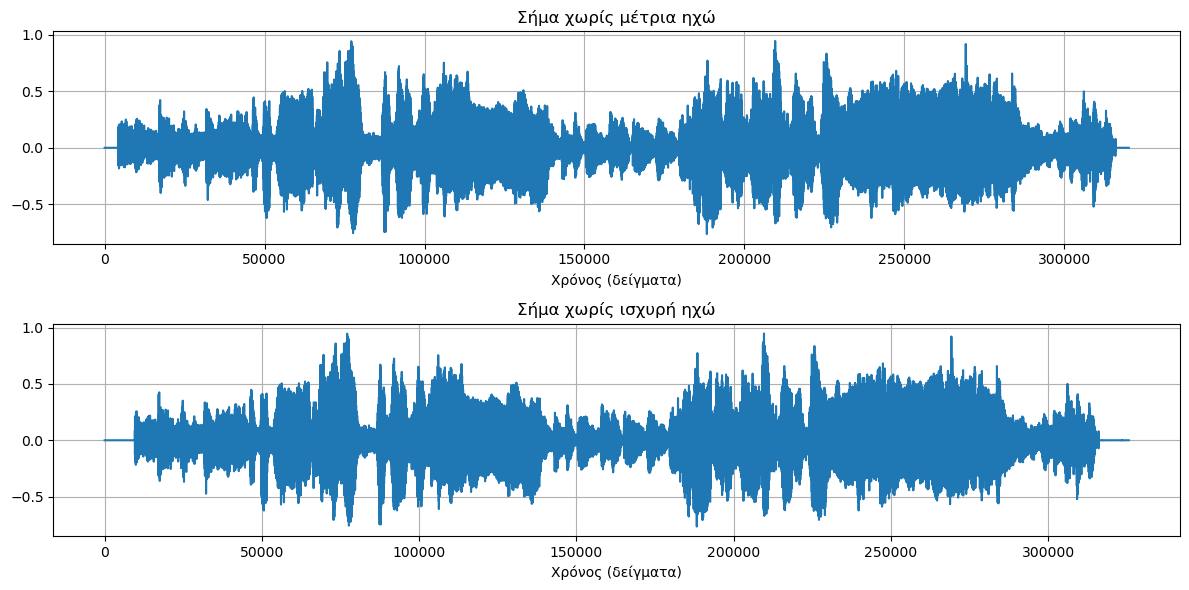

In [17]:
# Ας τυπώσουμε τα σήματα που μόλις παράξαμε.
plt.figure(figsize=(12,6))

plt.subplot(2, 1, 1)
plt.plot(y1)
plt.title("Σήμα χωρίς μέτρια ηχώ")
plt.xlabel('Χρόνος (δείγματα)')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(y2)
plt.title("Σήμα χωρίς ισχυρή ηχώ")
plt.xlabel('Χρόνος (δείγματα)')
plt.grid()

plt.tight_layout()
plt.show()
plt.close()

---
---